In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

from scipy import stats
import statsmodels.formula.api as smf

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

#for the animation plot video at the very bottom!
import matplotlib.animation as ani

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

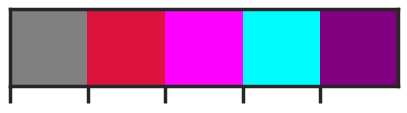

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Load some necessary variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

# First, load in the .npy arrays and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [7]:
all_rew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew.npy")
all_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew2.npy")
all_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_unrew.npy")

In [8]:
pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_cc_ls"

open_file = open(pkl_file, "rb")
CC_ls = pickle.load(open_file)
open_file.close()

CC_ls

['CC067431',
 'CC067432',
 'CC067432',
 'CC067489',
 'CC067489',
 'CC082255',
 'CC082255',
 'CC082257',
 'CC082257',
 'CC082257',
 'CC082260',
 'CC082260',
 'CC082260',
 'CC082263',
 'CC082263',
 'CC082263',
 'CC084621',
 'CC084621']

In [9]:
print('rew: {0}'.format(all_rew_arr.shape))
print('rew2: {0}'.format(all_rew2_arr.shape))
print('unrew: {0}'.format(all_unrew_arr.shape))

rew: (18, 384, 7350)
rew2: (18, 384, 7350)
unrew: (18, 384, 7350)


---

# Plot the VEP ch trace

### First, we have to define a function

In [10]:
def VEP_lines(data_array):
    groupA = []
    groupB = []
    for i in range(data_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            groupA.append(data_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            groupB.append(data_array[i])

    groupA_arr = np.array(groupA)
    groupB_arr = np.array(groupB)

    mean_A = groupA_arr.mean(axis=0)
    mean_B = groupB_arr.mean(axis=0)

    print('Group A array: {0}'.format(groupA_arr.shape))
    print('Group A mean: {0}'.format(mean_A.shape))

    print('Group B array: {0}'.format(groupB_arr.shape))
    print('Group B mean: {0}'.format(mean_B.shape))

    V1_A = mean_A[200:300, :]
    min_A = np.where(V1_A == np.amin(V1_A))
    min_ch_A = min_A[0][0] + 199
    print(min_ch_A)

    V1_B = mean_B[200:300, :]
    min_B = np.where(V1_B == np.amin(V1_B))
    min_ch_B = min_B[0][0] + 199
    print(min_ch_B)
    
    return mean_A, mean_B, min_ch_A, min_ch_B

### Second, apply the function to the three situations

In [11]:
# Rewarded with water
r1_meanA, r1_meanB, r1_minch_A, r1_minch_B = VEP_lines(all_rew_arr)

Group A array: (10, 384, 7350)
Group A mean: (384, 7350)
Group B array: (8, 384, 7350)
Group B mean: (384, 7350)
264
272


In [12]:
# Rewarded without water
r2_meanA, r2_meanB, r2_minch_A, r2_minch_B = VEP_lines(all_rew2_arr)

Group A array: (10, 384, 7350)
Group A mean: (384, 7350)
Group B array: (8, 384, 7350)
Group B mean: (384, 7350)
264
268


In [13]:
# Unrewarded
nr_meanA, nr_meanB, nr_minch_A, nr_minch_B = VEP_lines(all_unrew_arr)

Group A array: (10, 384, 7350)
Group A mean: (384, 7350)
Group B array: (8, 384, 7350)
Group B mean: (384, 7350)
264
272


### Finally, you can plot the graphs

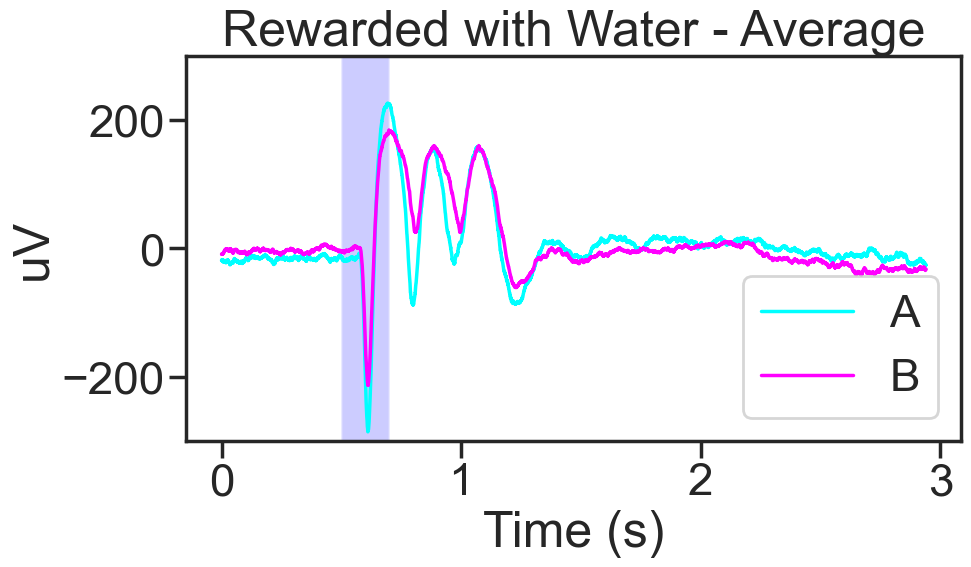

In [14]:
plt.figure(figsize=(10, 5))

mean_ch_traceA = r1_meanA[r1_minch_A,:]
time_arr2_A = np.linspace(0, mean_ch_traceA.shape[0]/sr, mean_ch_traceA.shape[0])

mean_ch_traceB = r1_meanB[r1_minch_B,:]
time_arr2_B = np.linspace(0, mean_ch_traceB.shape[0]/sr, mean_ch_traceB.shape[0])

plt.plot(time_arr2_A, mean_ch_traceA, label='A', color='cyan')
plt.plot(time_arr2_B, mean_ch_traceB, label='B', color='magenta')
plt.legend(loc="lower right")

plt.title('Rewarded with Water - Average')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\rew_VEP_trace.pdf", transparent=True)

plt.show()

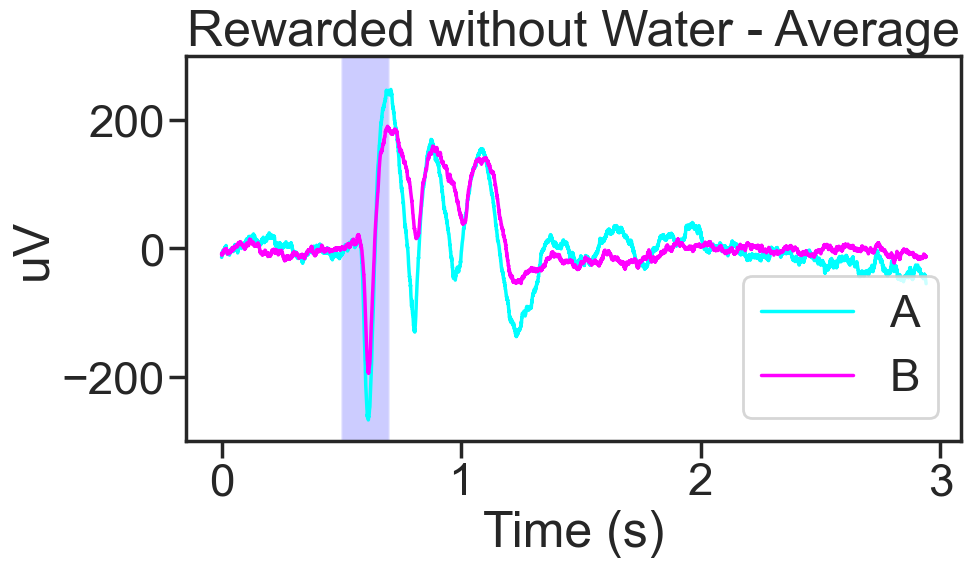

In [15]:
plt.figure(figsize=(10, 5))

mean_ch_traceA = r2_meanA[r2_minch_A,:]
time_arr2_A = np.linspace(0, mean_ch_traceA.shape[0]/sr, mean_ch_traceA.shape[0])

mean_ch_traceB = r2_meanB[r2_minch_B,:]
time_arr2_B = np.linspace(0, mean_ch_traceB.shape[0]/sr, mean_ch_traceB.shape[0])

plt.plot(time_arr2_A, mean_ch_traceA, label='A', color='cyan')
plt.plot(time_arr2_B, mean_ch_traceB, label='B', color='magenta')
plt.legend(loc="lower right")

plt.title('Rewarded without Water - Average')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\rew2_VEP_trace.pdf", transparent=True)

plt.show()

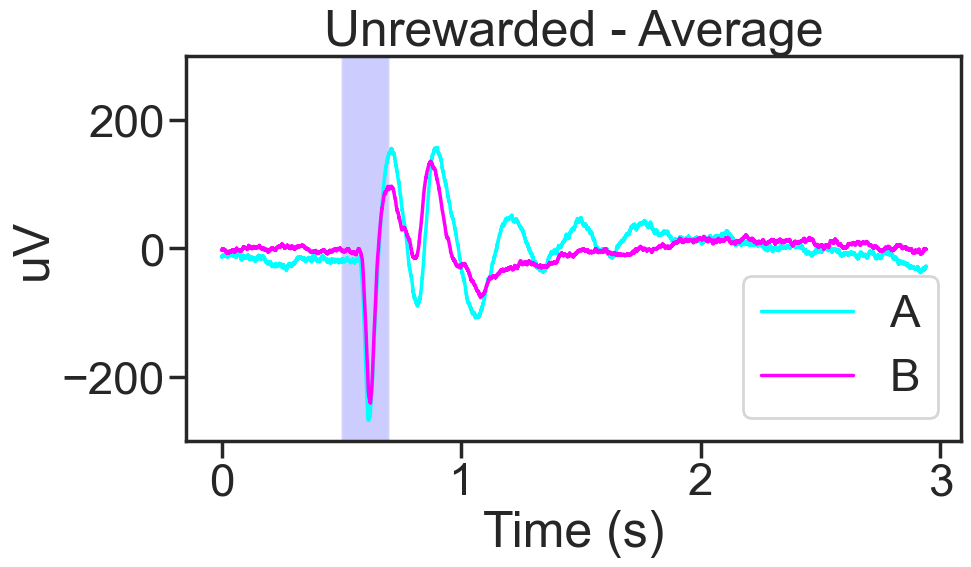

In [16]:
plt.figure(figsize=(10, 5))

mean_ch_traceA = nr_meanA[nr_minch_A,:]
time_arr2_A = np.linspace(0, mean_ch_traceA.shape[0]/sr, mean_ch_traceA.shape[0])

mean_ch_traceB = nr_meanB[nr_minch_B,:]
time_arr2_B = np.linspace(0, mean_ch_traceB.shape[0]/sr, mean_ch_traceB.shape[0])

plt.plot(time_arr2_A, mean_ch_traceA, label='A', color='cyan')
plt.plot(time_arr2_B, mean_ch_traceB, label='B', color='magenta')
plt.legend(loc="lower right")

plt.title('Unrewarded - Average')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\unrew_VEP_trace.pdf", transparent=True)

plt.show()

---

# Finding the VEP peaks in each situation


In [17]:
time_windows=[[0.55,0.7],   # VEP 1 time frame
              [0.71,0.85],  # VEP 2 time frame
              [0.86,1],     # VEP 3 time frame
              [1.05,1.15],  # VEP 4 time frame
              [1.2,1.4]]    # VEP 5 time frame


time_windows=[[i[0]*sr,i[1]*sr] for i in time_windows]
depth_bounds=[[200,300],[0,200]] #V1 bounds and hippocampus/Thalamus bounds


### First, we start by creating the dfs

In [18]:
def create_vep_df(array):
    V1vep1=array[:,depth_bounds[0][0]:depth_bounds[0][1],
                          int(time_windows[0][0]):int(time_windows[0][1])
                         ].min(axis=-1).min(axis=1)
    V1vep2=array[:,depth_bounds[0][0]:depth_bounds[0][1],
                          int(time_windows[1][0]):int(time_windows[1][1])
                         ].min(axis=-1).min(axis=1)
    V1vep3=array[:,depth_bounds[0][0]:depth_bounds[0][1],
                          int(time_windows[2][0]):int(time_windows[2][1])
                         ].min(axis=-1).min(axis=1)
    V1vep4=array[:,depth_bounds[0][0]:depth_bounds[0][1],
                          int(time_windows[3][0]):int(time_windows[3][1])
                         ].min(axis=-1).min(axis=1)
    V1vep5=array[:,depth_bounds[0][0]:depth_bounds[0][1],
                          int(time_windows[4][0]):int(time_windows[4][1])
                         ].min(axis=-1).min(axis=1)
#     V1vep6=array[:,depth_bounds[0][0]:depth_bounds[0][1],
#                           int(time_windows[5][0]):int(time_windows[5][1])
#                          ].min(axis=-1).min(axis=1)

# repeat the above lines for the .max() values and subtract them before adding to the dataframe below???


    V1vep1df=pd.DataFrame({'rec_ind':np.arange(V1vep1.shape[0])
                          ,'vepamp':V1vep1 
                          ,'vep':1})
    V1vep2df=pd.DataFrame({'rec_ind':np.arange(V1vep2.shape[0])
                          ,'vepamp':V1vep2,
                          'vep':2})
    V1vep3df=pd.DataFrame({'rec_ind':np.arange(V1vep3.shape[0])
                          ,'vepamp':V1vep3
                          ,'vep':3})
    V1vep4df=pd.DataFrame({'rec_ind':np.arange(V1vep4.shape[0])
                          ,'vepamp':V1vep4
                          ,'vep':4})
    V1vep5df=pd.DataFrame({'rec_ind':np.arange(V1vep5.shape[0])
                          ,'vepamp':V1vep5
                          ,'vep':5})
#      V1vep6df=pd.DataFrame({'rec_ind':np.arange(V1vep6.shape[0])
#                            ,'vepamp':V1vep6
#                            ,'vep':6})

    V1vepdf=pd.concat([V1vep1df, V1vep2df, V1vep3df, V1vep4df, V1vep5df]) #V1vep6df

    print('Number of vep peaks: {0}'.format(V1vepdf.vep.nunique()))
    print('Number of mice: {0}'.format(V1vepdf.rec_ind.nunique()))
    
    return V1vepdf

In [19]:
r1_V1vepdf = create_vep_df(all_rew_arr)
r2_V1vepdf = create_vep_df(all_rew2_arr)
nr_V1vepdf = create_vep_df(all_unrew_arr)

# r1_V1vepdf.head()

Number of vep peaks: 5
Number of mice: 18
Number of vep peaks: 5
Number of mice: 18
Number of vep peaks: 5
Number of mice: 18


### Second, we add in some additonal info to the dfs

In [20]:
for df in (r1_V1vepdf, r2_V1vepdf, nr_V1vepdf): #novel included here
    CC_dfls = []
    groupls = []
    setls = []
    for val in df.rec_ind:
        CC_dfls.append(CC_ls[val])
        if (CC_ls[val] == "CC082263") | (CC_ls[val] == "CC067489"):
            groupls.append("A")
            setls.append("1")
        elif (CC_ls[val] == "CC082260") | (CC_ls[val] == "CC084621"):
            groupls.append("A")
            setls.append("2")
        elif (CC_ls[val] == "CC082257") | (CC_ls[val] == "CC067431"):
            groupls.append("B")
            setls.append("1")
        elif (CC_ls[val] == "CC067432") | (CC_ls[val] == "CC082255"):
            groupls.append("B")
            setls.append("2")

    df["CC"] = CC_dfls
    df["group"] = groupls
    df["set"] = setls

r1_V1vepdf.head()

,rec_ind,vepamp,vep,CC,group,set
0,0,-223.387263,1,CC067431,B,1
1,1,-234.548244,1,CC067432,B,2
2,2,-162.427813,1,CC067432,B,2
3,3,-225.876590,1,CC067489,A,1
4,4,-308.637153,1,CC067489,A,1


### Finally, we can plot the quantification results

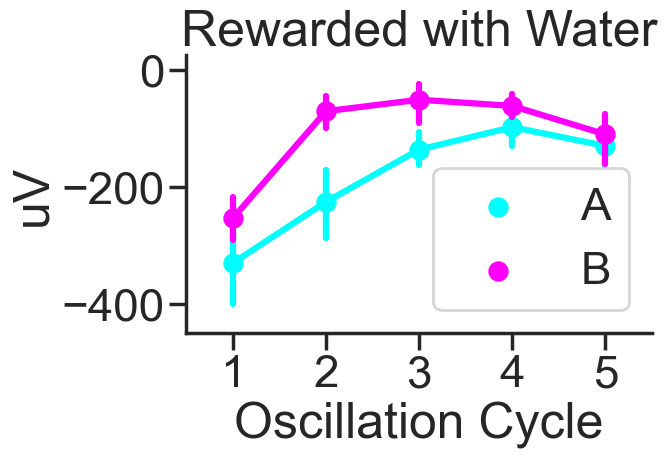

In [21]:
sns.catplot(data=r1_V1vepdf,
            x='vep',
            y='vepamp',
            kind='point',
            hue='group',
            legend=False,
            hue_order=['A','B'],
            height = 5,
            aspect=1.5,
            palette=sns.color_palette(['cyan', 'magenta'])
           )

plt.legend(loc="lower right")
plt.ylabel('uV')
plt.xlabel('Oscillation Cycle')
plt.title('Rewarded with Water')
plt.ylim([-450,25])

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\rew_VEP_peaks.pdf", transparent=True)

plt.show()

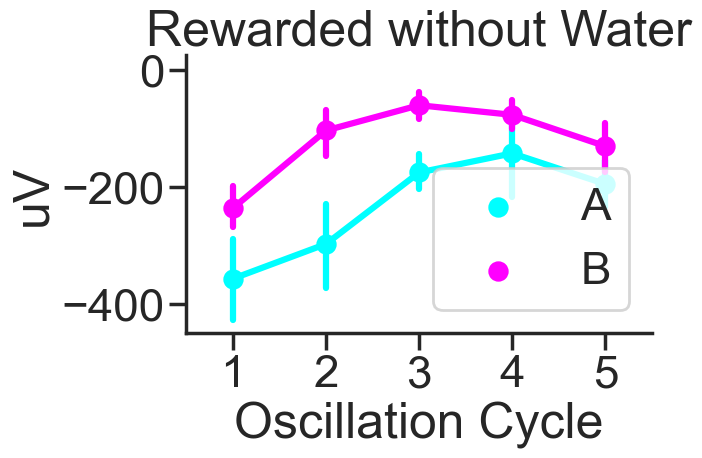

In [22]:
sns.catplot(data=r2_V1vepdf,
            x='vep',
            y='vepamp',
            kind='point',
            hue='group',
            legend=False,
            hue_order=['A','B'],
            height = 5,
            aspect=1.5,
            palette=sns.color_palette(['cyan', 'magenta'])
           )

plt.legend(loc="lower right")
plt.ylabel('uV')
plt.xlabel('Oscillation Cycle')
plt.title('Rewarded without Water')
plt.ylim([-450,25])

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\rew2_VEP_peaks.pdf", transparent=True)

plt.show()

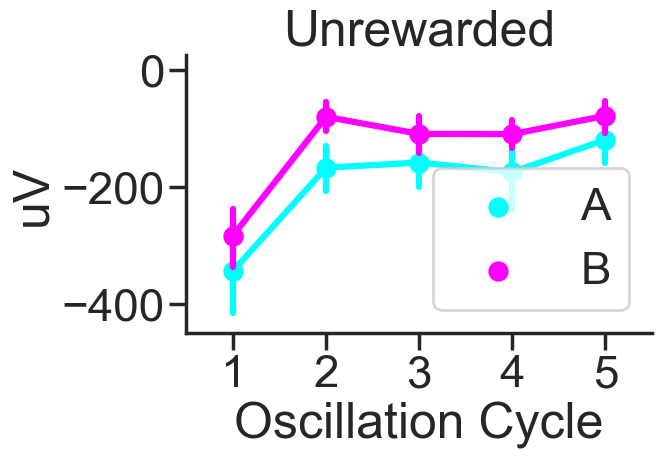

In [23]:
sns.catplot(data=nr_V1vepdf,
            x='vep',
            y='vepamp',
            kind='point',
            hue='group',
            legend=False,
            hue_order=['A','B'],
            height = 5,
            aspect=1.5,
            palette=sns.color_palette(['cyan', 'magenta'])
           )

plt.legend(loc="lower right")
plt.ylabel('uV')
plt.xlabel('Oscillation Cycle')
plt.title('Unrewarded')
plt.ylim([-450,25])

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\lfp\VEPs\2sec\unrew_VEP_peaks.pdf", transparent=True)

plt.show()

---

# Testing the stats about the above plots
### Overall test for the genotypes (WT vs FX)

In [24]:
def VEP_overall_stats(df):
    varA = df[df['group']=='A'].vepamp.values
    varB = df[df['group']=='B'].vepamp.values
    
    print('F-value degrees of freedom F x,y')
    print('x = {}'.format(5-1)) # 5 cycles
    print('y = {}'.format(varA.shape[0]+(varA.shape[0]+varB.shape[0])-2))
    
    return stats.ttest_ind(varA, varB), stats.f_oneway(varA, varB)

In [25]:
rew_stats, rew_f = VEP_overall_stats(r1_V1vepdf)
rew2_stats, rew2_f = VEP_overall_stats(r2_V1vepdf)
unrew_stats, unrew_f = VEP_overall_stats(nr_V1vepdf)

F-value degrees of freedom F x,y
x = 4
y = 138
F-value degrees of freedom F x,y
x = 4
y = 138
F-value degrees of freedom F x,y
x = 4
y = 138


### Individual tests for each vep peak

In [30]:
import scipy.stats as sstat

In [55]:
def VEP_peaks_MWUtest(df):
    stats_results = []
    fstats_results = []
    tukeytest_results = []
    for vep in df.vep.unique():
        foo_df = df[df['vep'] == vep]
        var1 = foo_df[foo_df['group'] == 'A'].vepamp.values
        var2 = foo_df[foo_df['group'] == 'B'].vepamp.values
        result = stats.mannwhitneyu(var1, var2)
        stats_results.append(vep)
        stats_results.append(result)
    return stats_results

In [57]:
rew_stats = VEP_peaks_MWUtest(r1_V1vepdf)
rew2_stats = VEP_peaks_MWUtest(r2_V1vepdf)
unrew_stats = VEP_peaks_MWUtest(nr_V1vepdf)

print('rew')
for idx,val in enumerate(rew_stats):
    print(val) #this is testing WT->FX for each cycle
print('rew2')
for idx,val in enumerate(rew2_stats):
    print(val) #this is testing WT->FX for each cycle
print('unrew')
for idx,val in enumerate(unrew_stats):
    print(val) #this is testing WT->FX for each cycle

rew
1
MannwhitneyuResult(statistic=20.0, pvalue=0.08284513326963502)
2
MannwhitneyuResult(statistic=4.0, pvalue=0.0015911841842640702)
3
MannwhitneyuResult(statistic=9.0, pvalue=0.00667179346719265)
4
MannwhitneyuResult(statistic=23.0, pvalue=0.14221867447100317)
5
MannwhitneyuResult(statistic=30.0, pvalue=0.39812781090907634)
rew2
1
MannwhitneyuResult(statistic=16.0, pvalue=0.03660091820858935)
2
MannwhitneyuResult(statistic=5.0, pvalue=0.0021508318145148837)
3
MannwhitneyuResult(statistic=3.0, pvalue=0.0011684898107331787)
4
MannwhitneyuResult(statistic=20.0, pvalue=0.08284513326963502)
5
MannwhitneyuResult(statistic=17.0, pvalue=0.04536612331676102)
unrew
1
MannwhitneyuResult(statistic=31.0, pvalue=0.4496339465536672)
2
MannwhitneyuResult(statistic=10.0, pvalue=0.008694130557126317)
3
MannwhitneyuResult(statistic=23.0, pvalue=0.14221867447100317)
4
MannwhitneyuResult(statistic=29.0, pvalue=0.3503483743674619)
5
MannwhitneyuResult(statistic=23.0, pvalue=0.14221867447100317)


In [35]:
def VEP_peaks_stats(df):
    stats_results = []
    fstats_results = []
    tukeytest_results = []
    for vep in df.vep.unique():
        foo_df = df[df['vep'] == vep]
        var1 = foo_df[foo_df['group'] == 'A'].vepamp.values
        var2 = foo_df[foo_df['group'] == 'B'].vepamp.values
        result = stats.ttest_ind(var1, var2)
        fresult = stats.f_oneway(var1, var2)
        res = sstat.tukey_hsd(var1, var2)

        stats_results.append(vep)
        stats_results.append(result)
        fstats_results.append(vep)
        fstats_results.append(fresult)
        tukeytest_results.append(vep)
        tukeytest_results.append(res)
    
    return stats_results, fstats_results, tukeytest_results

In [36]:
rew_stats, rew_fstats, rew_tukey = VEP_peaks_stats(r1_V1vepdf)
rew2_stats, rew2_fstats, rew2_tukey = VEP_peaks_stats(r2_V1vepdf)
unrew_stats, unrew_fstats, unrew_tukey = VEP_peaks_stats(nr_V1vepdf)

In [43]:
for idx,val in enumerate(rew_tukey):
    print(val) #this is testing WT->FX for each cycle

1
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -76.574     0.095  -168.003    14.855
 (1 - 0)     76.574     0.095   -14.855   168.003

2
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)   -154.979     0.001  -233.801   -76.156
 (1 - 0)    154.979     0.001    76.156   233.801

3
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -85.241     0.002  -134.301   -36.180
 (1 - 0)     85.241     0.002    36.180   134.301

4
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -36.243     0.095   -79.576     7.090
 (1 - 0)     36.243     0.095    -7.090    79.576

5
Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper

### Linear Mixed Model analysis
First, for the Amp values x Vep # with a comparison between groups

Second, for the Amp values x group with a comparison between Vep #

In [48]:
def LMM_stats(df):
    md2 = smf.mixedlm("vepamp ~ group", data=df, groups=df["vep"], re_formula="~group")
    mdf2 = md2.fit(method=["lbfgs"])
    print(mdf2.summary())
    return mdf2

In [52]:
r1_mdf2 = LMM_stats(r1_V1vepdf)
print(r1_mdf2.pvalues)

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      vepamp   
No. Observations:        90           Method:                  REML     
No. Groups:              5            Scale:                   4512.7660
Min. group size:         18           Log-Likelihood:          -507.5524
Max. group size:         18           Converged:               Yes      
Mean group size:         18.0                                           
------------------------------------------------------------------------
                         Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
------------------------------------------------------------------------
Intercept               -184.384   42.233 -4.366 0.000 -267.160 -101.608
group[T.B]                74.557   23.514  3.171 0.002   28.472  120.643
Group Var               8466.993   96.192                               
Group x group[T.B] Cov -1896.650   41.252                            

In [53]:
r2_mdf2 = LMM_stats(r2_V1vepdf)
print(r2_mdf2.pvalues)

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      vepamp   
No. Observations:        90           Method:                  REML     
No. Groups:              5            Scale:                   7014.7762
Min. group size:         18           Log-Likelihood:          -524.4902
Max. group size:         18           Converged:               Yes      
Mean group size:         18.0                                           
------------------------------------------------------------------------
                         Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
------------------------------------------------------------------------
Intercept               -233.954   40.269 -5.810 0.000 -312.880 -155.028
group[T.B]               111.982   23.643  4.736 0.000   65.643  158.322
Group Var               7406.600   70.145                               
Group x group[T.B] Cov -2334.553   34.191                            

In [54]:
nr_mdf2 = LMM_stats(nr_V1vepdf)
print(nr_mdf2.pvalues)

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      vepamp   
No. Observations:       90           Method:                  REML     
No. Groups:             5            Scale:                   5085.3052
Min. group size:        18           Log-Likelihood:          -510.7708
Max. group size:        18           Converged:               Yes      
Mean group size:        18.0                                           
-----------------------------------------------------------------------
                        Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
-----------------------------------------------------------------------
Intercept              -193.121   40.010 -4.827 0.000 -271.539 -114.703
group[T.B]               60.459   15.157  3.989 0.000   30.752   90.166
Group Var              7495.427   90.221                               
Group x group[T.B] Cov -137.092   42.743                               
group[T.B

C:\Users\AChub_Lab\anaconda3\envs\mzim\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


---

---

---

---

---

---

---

---

---

# imshow() plot (average traces for single group)

In [ ]:
r1_meanA.shape

In [ ]:
plt.figure(figsize=(6,6))

user_choice = input('What stimulus type? ')

if user_choice == 'rew':
    plot_data = r1_meanA
    plot_title = 'Rewarded with water'
    im = plt.imshow(plot_data, aspect='auto', origin='lower', 
                    vmin=(-400), vmax=(300), cmap='viridis_r')
    cb_label = 'uV'
elif user_choice =='rew2':
#     plot_data = car2_scale
    plot_title = 'Rewarded without water'
    im = plt.imshow(plot_data, aspect='auto', origin='lower', 
                    vmin=(-400), vmax=(300), cmap='viridis_r')
    cb_label = 'uV'
elif user_choice =='unrew':
#     plot_data = car3_scale
    plot_title = 'Unrewarded'
    im = plt.imshow(plot_data, aspect='auto', origin='lower', 
                    vmin=(-400), vmax=(300), cmap='viridis_r')
    cb_label = 'uV'

_ = plt.colorbar(im, fraction=0.036, pad=0.04, label=cb_label)
_ = plt.xlabel('Time (s)')
_ = plt.ylabel('Channel #')
_ = plt.xticks(ticks = time_plot, labels = time_arr)
_ = plt.title(plot_title)
_ = plt.tick_params(axis='both', labelsize=15)
_ = plt.axvspan((0.5*sr), (0.7*sr), facecolor='r', alpha=0.15)

# _ = plt.axhline(surface_ch, color='magenta', linestyle='--', alpha=0.75)
# _ = plt.axhline(V1_hip_ch, color='magenta', linestyle='--', alpha=0.75)
# _ = plt.axhline(Hip_thal_ch, color='magenta', linestyle='--', alpha=0.75)
# _ = plt.axhline(CA1_DG_ch, color='blue', linestyle=':', alpha=0.75)

# _ = plt.axvline((sr*1.5), color='black', alpha=0.50) #for reward

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\BME Summer Seminar\LFP_pre_regions.pdf", transparent=True)

# plot strongest ch vep (group average)

In [ ]:
V1_range = r1_meanA[200:300, :]

min_val = np.where(V1_range == np.amin(V1_range))
min_channel = min_val[0][0] + 199

print(min_channel)

In [ ]:
plt.figure(figsize=(10, 4))

ch_choice = min_channel     # just choose a channel based off of the LFP plot above

mean_ch_trace = plot_data[min_channel,:]
time_arr2 = np.linspace(0, mean_ch_trace.shape[0]/sr, mean_ch_trace.shape[0])
plt.plot(time_arr2, mean_ch_trace)
plt.title('Channel {0}'.format(min_channel))

plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')
plt.axhline(0, alpha=0.5, color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.tick_params(axis='both', labelsize=15)

sns.despine()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\BME Summer Seminar\example_VEP_preV1.pdf", transparent=True)

plt.show()

# Plot VEP for each channel (group average)

In [ ]:
for ch in range(plot_data.shape[0]):
    mean_ch_trace = plot_data[ch,:]
    time_arr = np.linspace(0, mean_ch_trace.shape[0]/sr, mean_ch_trace.shape[0])
    
    plt.figure(figsize=(10, 3))
    plt.plot(time_arr, mean_ch_trace)
    
    plt.title('Channel {0}'.format(ch))
    plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')
    plt.axhline(0, alpha=0.5, color='k', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('uV')
    plt.tick_params(axis='both', labelsize=15)
    plt.show()

# Animated plot of all channels (group average)

In [ ]:
fig = plt.figure()

time_arr = np.linspace(0, plot_data.shape[1]/sr, plot_data.shape[1])

def buildme(i=int):
    plt.cla()
    plt.title('Channel {0}'.format(i))
    plt.plot(time_arr, plot_data[i,:], color='skyblue') #note it only returns the dataset, up to the point i
    plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')
    plt.axhline(0, alpha=0.5, color='k', linestyle='--')
    plt.ylim([-400,400])
    plt.ylabel('uV')
    plt.xlabel('Time (s)')

animator = ani.FuncAnimation(fig, buildme, frames=320, interval=150)

# animator.save(r"C:\Users\AChub_Lab\Desktop\rew_animation.gif")

writerVideo = ani.FFMpegWriter(fps=15)
animator.save(r'C:\Users\AChub_Lab\Desktop\mz_temp\2s_rew.mp4', writer=writerVideo)

plt.close()


---

---

---